In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seaborn theme — applies a clean background to all charts
sns.set_theme(style='whitegrid', palette='muted')

%matplotlib inline

In [2]:
cols = ['CreditScore','Geography','Gender','Age','Tenure',
        'Balance','NumOfProducts','IsActiveMember','EstimatedSalary','Exited']

churn = pd.read_csv(
    r"C:\\Users\\LENOVO\\Downloads\\archive (2)\\Churn_Modelling.csv",
    usecols=cols
)

# Create a readable label column for Exited
churn['Status'] = churn['Exited'].map({0: 'Stayed', 1: 'Exited'})

churn.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Status
0,619,France,Female,42,2,0.00,1,1,101348.88,1,Exited
1,608,Spain,Female,41,1,83807.86,1,1,112542.58,0,Stayed
2,502,France,Female,42,8,159660.80,3,0,113931.57,1,Exited
3,699,France,Female,39,1,0.00,2,0,93826.63,0,Stayed
4,850,Spain,Female,43,2,125510.82,1,1,79084.10,0,Stayed


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24228\135838363.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=churn, x='Status', y='Age',


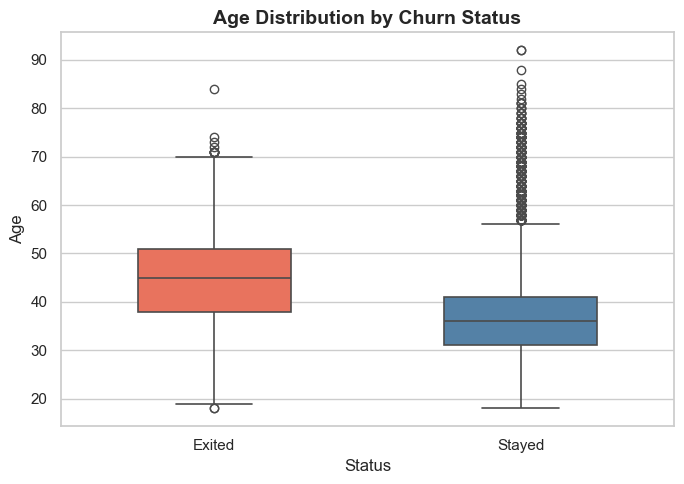

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=churn, x='Status', y='Age',
            palette={'Stayed': 'steelblue', 'Exited': 'tomato'},
            width=0.5, linewidth=1.2, ax=ax)

ax.set_title('Age Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Age')

plt.tight_layout()
plt.show()

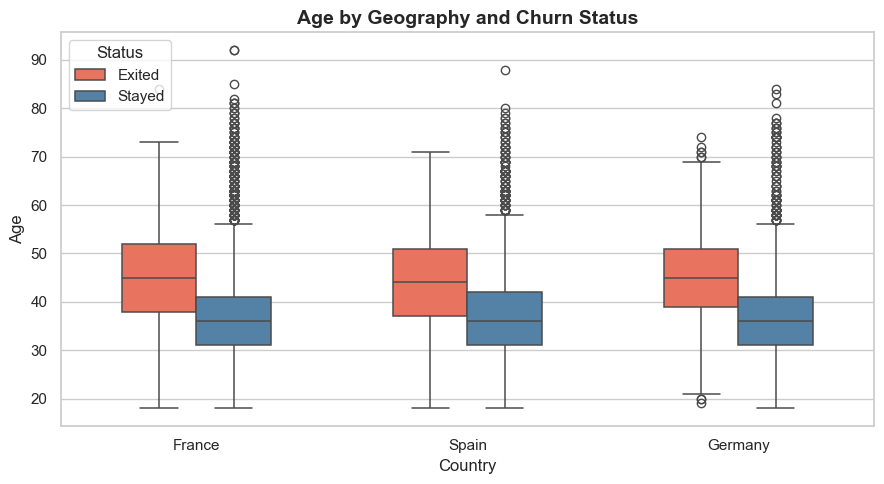

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=churn, x='Geography', y='Age', hue='Status',
            palette={'Stayed': 'steelblue', 'Exited': 'tomato'},
            width=0.55, linewidth=1.1, ax=ax)

ax.set_title('Age by Geography and Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Age')
ax.legend(title='Status')

plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24228\1727530988.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sample, x='Status', y='Balance',
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_24228\1727530988.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sample, x='Status', y='Balance',


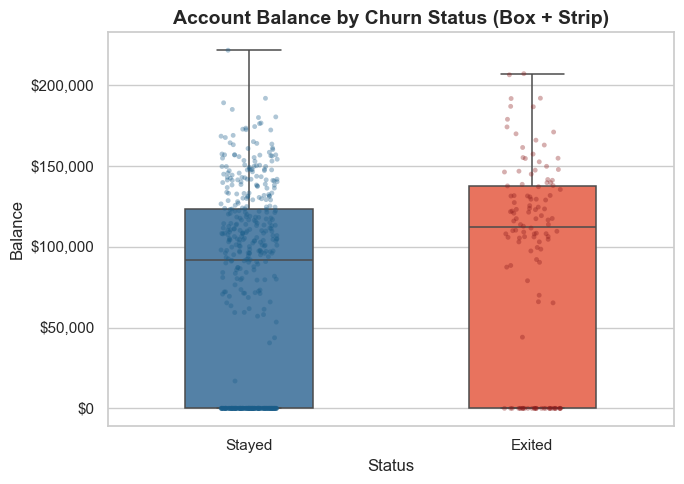

In [6]:
sample = churn.sample(600, random_state=1)

fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=sample, x='Status', y='Balance',
            palette={'Stayed': 'steelblue', 'Exited': 'tomato'},
            width=0.45, linewidth=1.1, fliersize=0, ax=ax)  # hide box outliers

sns.stripplot(data=sample, x='Status', y='Balance',
              palette={'Stayed': '#1a5e8a', 'Exited': '#8b1a1a'},
              alpha=0.35, jitter=True, size=3.5, ax=ax)

ax.set_title('Account Balance by Churn Status (Box + Strip)', fontsize=14, fontweight='bold')
ax.set_xlabel('Status')
ax.set_ylabel('Balance')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

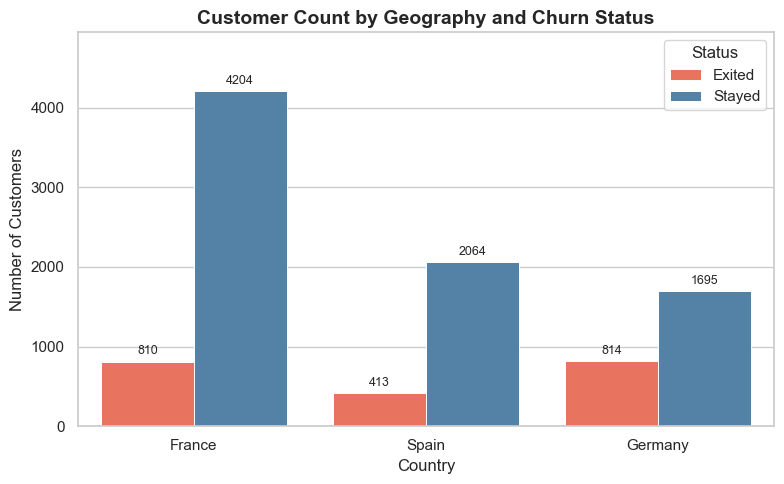

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(data=churn, x='Geography', hue='Status',
              palette={'Stayed': 'steelblue', 'Exited': 'tomato'},
              edgecolor='white', linewidth=0.7, ax=ax)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

ax.set_title('Customer Count by Geography and Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Country')
ax.set_ylabel('Number of Customers')
ax.legend(title='Status')
ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

plt.tight_layout()
plt.show()

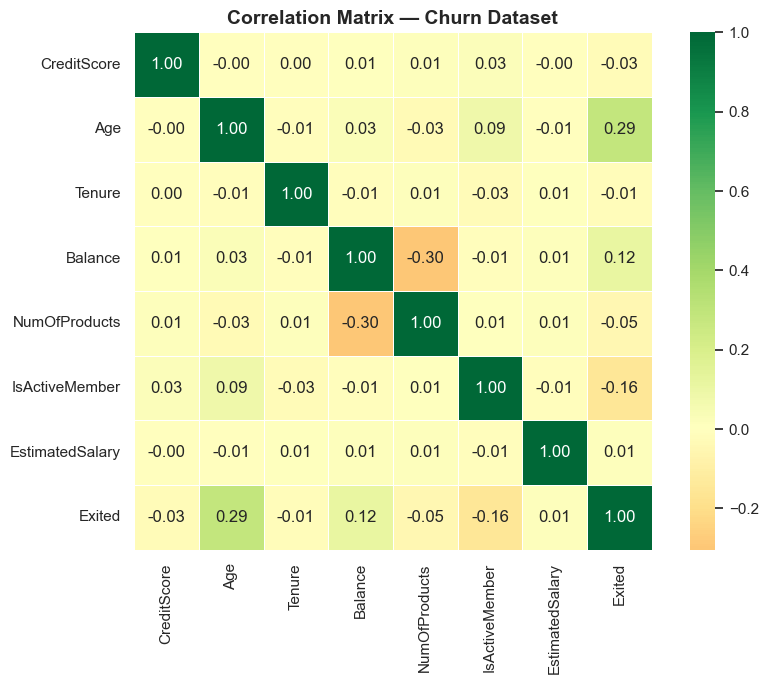

In [8]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
             'NumOfProducts', 'IsActiveMember', 'EstimatedSalary', 'Exited']

corr = churn[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(corr,
            annot=True,          
            fmt='.2f',          
            cmap='RdYlGn',       
            center=0,            
            linewidths=0.5,
            linecolor='white',
            square=True,
            ax=ax)

ax.set_title('Correlation Matrix — Churn Dataset', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

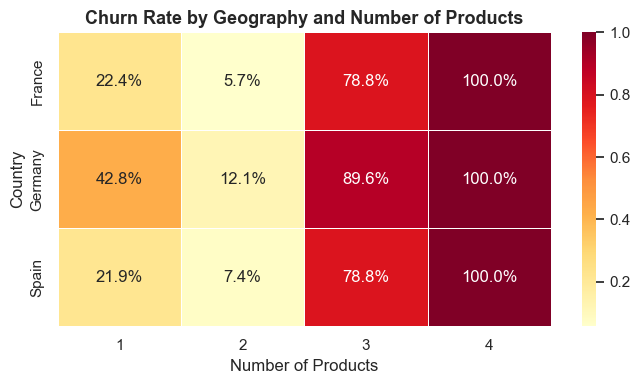

In [9]:
pivot = (churn
         .groupby(['Geography', 'NumOfProducts'])['Exited']
         .mean()
         .unstack()
         .round(3))

fig, ax = plt.subplots(figsize=(7, 4))

sns.heatmap(pivot,
            annot=True, fmt='.1%',   # format as percentage
            cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            ax=ax)

ax.set_title('Churn Rate by Geography and Number of Products',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Products')
ax.set_ylabel('Country')

plt.tight_layout()
plt.show()